# Chip Heat Transfer Modeling
## 1D Thermal Resistance Model of a Chip Stack
In this notebook, we derive and apply the heat equation to a typical modern chip stack.

### 1. The Heat Equation
For steady-state 1D conduction with heat generation $\dot{q}$:
$$\frac{d}{dx}\left(k \frac{dT}{dx}\right) + \dot{q} = 0$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

print("Setup complete.")

Setup complete.


### 2. Modeling the Chip Stack

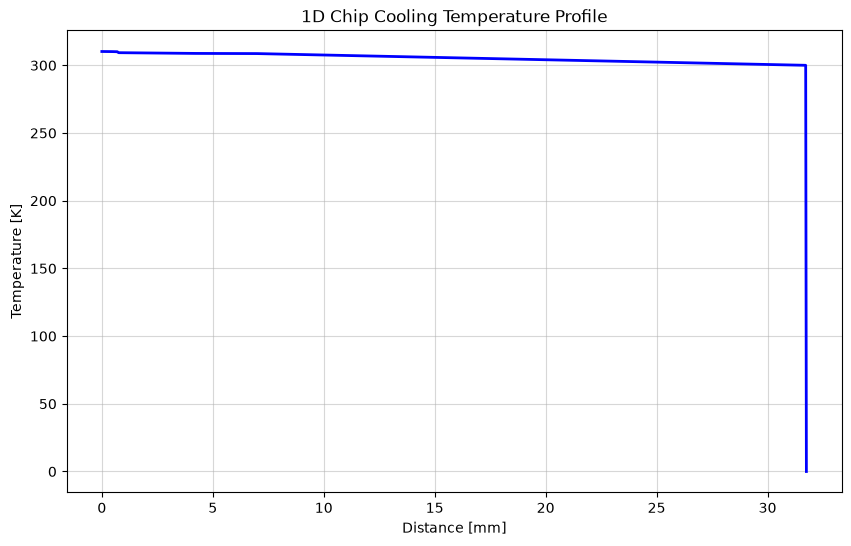

In [2]:
# Layer properties (thickness in m, conductivity in W/mK)
layers = [
    {'name': 'Silicon', 'L': 0.0007, 'k': 140, 'q_gen': 1e8},
    {'name': 'TIM', 'L': 0.00005, 'k': 5, 'q_gen': 0},
    {'name': 'Spreader', 'L': 0.003, 'k': 390, 'q_gen': 0},
    {'name': 'Vapor Chamber', 'L': 0.003, 'k': 5000, 'q_gen': 0},
    {'name': 'Heat Sink', 'L': 0.025, 'k': 200, 'q_gen': 0},
]

total_L = sum(l['L'] for l in layers)
x_interfaces = [0.0]
current_x = 0.0
for l in layers:
    current_x += l['L']
    x_interfaces.append(current_x)
x_interfaces = np.array(x_interfaces)

T_ambient = 300.0
q_gen_si = layers[0]['q_gen']
L_si = layers[0]['L']
Q = q_gen_si * L_si

T_at_interfaces = np.zeros(len(layers) + 1)
T_at_interfaces[-1] = T_ambient

for i in range(len(layers)-1, -1, -1):
    L_i = layers[i]['L']
    k_i = layers[i]['k']
    q_gen_i = layers[i]['q_gen']
    if q_gen_i == 0:
        T_at_interfaces[i] = T_at_interfaces[i+1] + Q * L_i / k_i
    else:
        T_at_interfaces[i] = T_at_interfaces[i+1] + (q_gen_i * L_i**2) / (2 * k_i)

x_fine = np.linspace(0, total_L, 1000)
T_fine = np.zeros_like(x_fine)

for i in range(len(layers)):
    idx_start = np.searchsorted(x_fine, x_interfaces[i])
    idx_end = np.searchsorted(x_fine, x_interfaces[i+1])
    x_layer = x_fine[idx_start:idx_end]
    if len(x_layer) == 0: continue
    L_i = layers[i]['L']
    k_i = layers[i]['k']
    q_gen_i = layers[i]['q_gen']
    T_start = T_at_interfaces[i]
    if q_gen_i == 0:
        T_fine[idx_start:idx_end] = T_at_interfaces[i] - (Q/k_i) * (x_layer - x_interfaces[i])
    else:
        T_fine[idx_start:idx_end] = T_at_interfaces[0] - (q_gen_i * x_layer**2) / (2 * k_i)

plt.figure(figsize=(10, 6))
plt.plot(x_fine * 1000, T_fine, 'b-', linewidth=2)
plt.xlabel('Distance [mm]')
plt.ylabel('Temperature [K]')
plt.title('1D Chip Cooling Temperature Profile')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()